In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

### Get File path and load the csv data

In [ ]:
from util.data_path import cassava_price_avg

In [ ]:
wide = pd.read_csv(cassava_price_avg)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

### Set the training dataset and the predicted data

In [16]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [ ]:
y_train = train["price"].asfreq("MS")
y_test = future["price"].asfreq("MS")

SEQ_LEN = 12
PRED_LEN = 12

### Predict the data for the next year

In [19]:
sf_data = (
    y_train.rename("y")
    .to_frame()
    .assign(ds=lambda df: df.index, unique_id="cassava")
    .reset_index(drop=True)
)

sf = StatsForecast(
    models=[
        AutoARIMA(
            season_length=12,  # monthly
            approximation=False,
        )
    ],
    freq="MS",  # month start
)

### Compare The Error of a predicted data and the actual data in a table format

In [20]:
sf_forecasts = sf.fit_predict(df=sf_data, h=12)
arima_sf = sf_forecasts.set_index("ds")["AutoARIMA"]


error = y_test - arima_sf
abs_error = abs(error)

mae_arima = mean_absolute_error(y_test, arima_sf)
error = pd.DataFrame(
    {
        "actual": y_test,
        "arima_sf": arima_sf,
        "mae_arima": abs_error,
    }
)
print(error.round(3))
print(f"MAE ARIMA: {mae_arima:.3f}")

            actual  arima_sf  mae_arima
2024-01-01    3.65     3.652      0.002
2024-02-01    3.65     3.644      0.006
2024-03-01    3.57     3.644      0.074
2024-04-01    3.24     3.644      0.404
2024-05-01    3.19     3.644      0.454
2024-06-01    3.09     3.644      0.554
2024-07-01    3.06     3.644      0.584
2024-08-01    2.95     3.644      0.694
2024-09-01    2.86     3.644      0.784
2024-10-01    2.65     3.644      0.994
2024-11-01    2.60     3.644      1.044
2024-12-01    2.32     3.644      1.324
MAE ARIMA: 0.577


### Plot The predicted data compare to an actual data

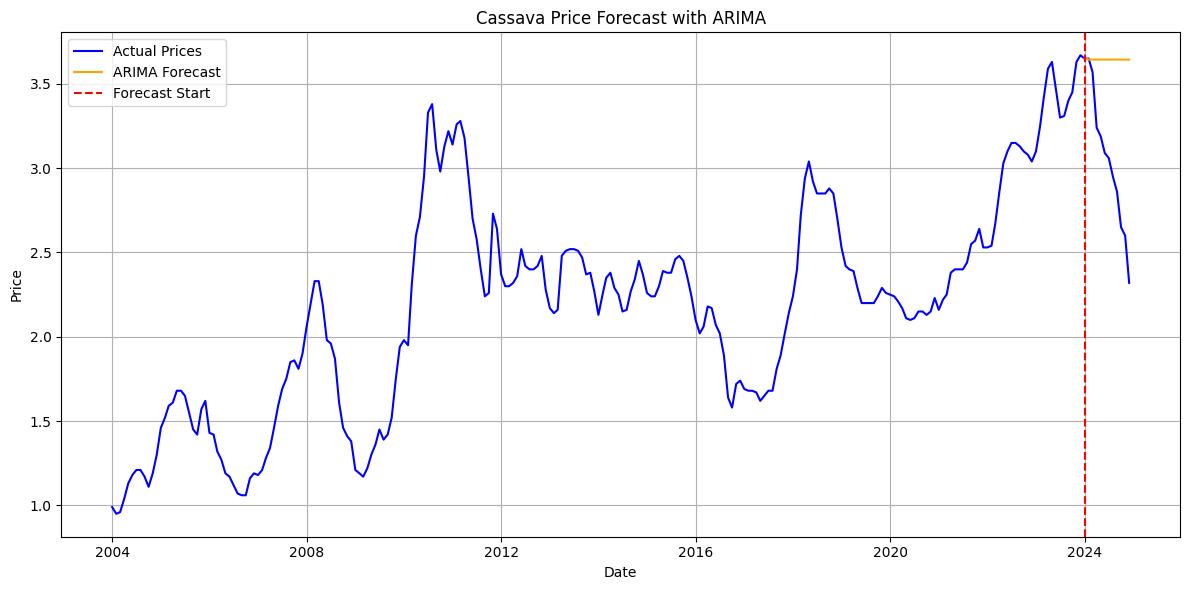

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(arima_sf.index, arima_sf, label="ARIMA Forecast", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_2567}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Cassava Price Forecast with ARIMA")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()